In [7]:
import os
PATH = os.getcwd()
os.environ['EZGAL_MODELS']  = f'{PATH}/models/'
os.environ['EZGAL_FILTERS'] = f'{PATH}/filters/'

import ezgal
import numpy as np
import matplotlib.pyplot as plt
import fitsio

In [26]:
#SWAP BETWEEN THESE TO COMPUTE IT FOR DIFFERENT SETUPS

bands  = ['lsst_u', 'lsst_g', 'lsst_r', 'lsst_i', 'lsst_z', 'lsst_y', 'roman_F106', 'roman_F129', 'roman_F158', 'roman_F184']
survey = 'lsst_roman'

# bands = ['roman_F106', 'roman_F129', 'roman_F158', 'roman_F184']
# survey = 'roman'

# bands  = ['lsst_u', 'lsst_g', 'lsst_r', 'lsst_i', 'lsst_z', 'lsst_y']
# survey = 'lsst'

# Compute mag*(z)

In [27]:
def make_mstar(
    bc03_model_fits_path: str,
    out_path: str = "mstar_sdss_r03.fit",
    zf: float = 3.0,
    zmin: float = 0.01,
    zmax: float = 1.5,
    dz: float = 0.01,
    # redMaPPer normalization:
    norm_z: float = 0.2,
    norm_band: str = "sloan_i",
    norm_m: float = 17.85,
    # output band:
    out_band: str = "sloan_r",
    survey_name: str = "sdss",
    band_header_value: str = "r03",
):
    """
    Generate m*(z) for SDSS r-band in the redMaPPer convention.

    Parameters
    ----------
    bc03_model_fits_path
        Path to an EzGal-ready BC03 SSP FITS model file (solar Z, Salpeter IMF).
        Example name often looks like 'bc03_ssp_z_0.02_...salp....fits' depending on your distribution.
    out_path
        Output FITS file path (e.g. mstar_sdss_r03.fit).
    zf
        Formation redshift (default 3.0) per redMaPPer. :contentReference[oaicite:3]{index=3}
    zmin, zmax, dz
        Redshift grid to tabulate.
    norm_z, norm_band, norm_m
        Normalize model so m(norm_band) at norm_z equals norm_m (17.85 at z=0.2 in SDSS i). :contentReference[oaicite:4]{index=4}
    out_band
        Filter name in EzGal for SDSS r-band ('sloan_r' is typical).
    survey_name, band_header_value
        Header keywords for redMaPPer compatibility. :contentReference[oaicite:5]{index=5}
    """

    # Load SSP model
    model = ezgal.model(bc03_model_fits_path)

    # Build z grid
    zs = np.arange(zmin, zmax + 0.5 * dz, dz, dtype=float)

    # Compute apparent magnitudes (un-normalized) for the normalization band and output band.
    # NOTE: function name in EzGal is "get_apparent_mags" in current releases.
    m_norm = np.asarray(model.get_apparent_mags(zf, filters=norm_band, zs=zs), dtype=float)
    m_out  = np.asarray(model.get_apparent_mags(zf, filters=out_band,  zs=zs), dtype=float)

    # Find model's magnitude at norm_z (interpolate on our grid)
    m_norm_at_normz = np.interp(norm_z, zs, m_norm)

    # Apply a constant magnitude offset so that m_norm(norm_z) == norm_m.
    # Magnitudes shift additively under a flux normalization.
    delta = norm_m - m_norm_at_normz
    mstar = m_out + delta

    # Prepare output table
    z_col = zs.astype("f4")
    m_col = mstar.astype("f4")

    hdr = fitsio.FITSHDR()
    hdr["SURVEY"] = survey_name
    hdr["BAND"]   = band_header_value

    data = np.empty(len(z_col), dtype=[("Z", "f4"), ("MSTAR", "f4")])
    data["Z"]     = z_col
    data["MSTAR"] = m_col

    fitsio.write(out_path, data, header=hdr, clobber=True)

    return zs, mstar

In [28]:
bc03_path = "bc03_ssp_z_0.02_salp.model"

for band in bands:
    
    zs, mstar = make_mstar(
        bc03_model_fits_path = bc03_path,
        out_band = band,
        out_path = f"{PATH}/mstar/mstar_{survey}_{band.split('_')[1]}03.fit",
        zmax=2, dz=0.005,
        survey_name = survey
    )

    print(f"Wrote mstar_{band}03.fit with", len(zs), "rows")
    print("m*(z=0.2) in r-band =", np.interp(0.2, zs, mstar))

/home/dhayaa/Roman/RedmapperRoman/calibdata/models/bc03_ssp_z_0.02_salp.model
Wrote mstar_lsst_u03.fit with 399 rows
m*(z=0.2) in r-band = 21.26804724859563
/home/dhayaa/Roman/RedmapperRoman/calibdata/models/bc03_ssp_z_0.02_salp.model
Wrote mstar_lsst_g03.fit with 399 rows
m*(z=0.2) in r-band = 19.5907501101168
/home/dhayaa/Roman/RedmapperRoman/calibdata/models/bc03_ssp_z_0.02_salp.model
Wrote mstar_lsst_r03.fit with 399 rows
m*(z=0.2) in r-band = 18.33541206597554
/home/dhayaa/Roman/RedmapperRoman/calibdata/models/bc03_ssp_z_0.02_salp.model
Wrote mstar_lsst_i03.fit with 399 rows
m*(z=0.2) in r-band = 17.83243526935196
/home/dhayaa/Roman/RedmapperRoman/calibdata/models/bc03_ssp_z_0.02_salp.model
Wrote mstar_lsst_z03.fit with 399 rows
m*(z=0.2) in r-band = 17.55013173770275
/home/dhayaa/Roman/RedmapperRoman/calibdata/models/bc03_ssp_z_0.02_salp.model
Wrote mstar_lsst_y03.fit with 399 rows
m*(z=0.2) in r-band = 17.32953593750633
/home/dhayaa/Roman/RedmapperRoman/calibdata/models/bc03_ssp

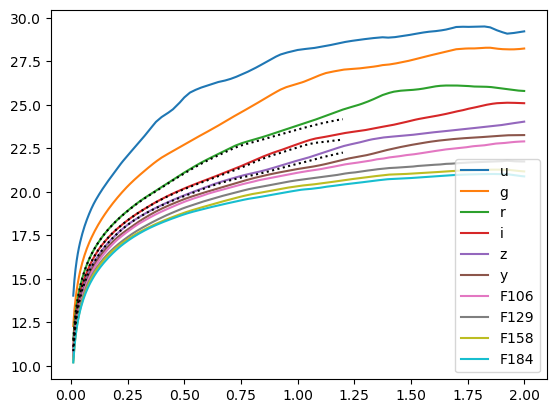

In [29]:
for b in bands:
    
    X = fitsio.read(f'{PATH}/mstar/mstar_{b}03.fit')

    plt.plot(X['Z'], X['MSTAR'], label = b.split('_')[1])
    
plt.legend()


for i in 'riz':
    
    X = fitsio.read(f'/home/dhayaa/DECADE/redmapper/redmapper/data/mstar/mstar_lsst_{i}03.fit')
    plt.plot(X['Z'], X['MSTAR'], color = 'k', ls = ':')

# Make color(z)

In [30]:
def make_bc03_colors(
    bc03_model_path: str,
    out_path: str = "bc03_colors_sdss.fit",
    zf: float = 3.0,
    zmin: float = 0.0,
    zmax: float = 1.0,
    dz: float = 0.005,
    survey_name: str = "sdss",
    band_list: list = ['lsst_u', 'lsst_g', 'lsst_r', 'lsst_i', 'lsst_z']
):
    """
    Create redMaPPer-style BC03 color initial-guess file for SDSS.

    Output format per redMaPPer how-to:
      header: SURVEY, BAND
      dtype:  Z (f4), COLOR (f4, n_color)  where n_color depends on BAND string
    :contentReference[oaicite:3]{index=3}
    """

    # Validate
    bands = band_list
    n_color = len(bands) - 1
    if n_color < 1:
        raise ValueError("band_string must contain at least 2 bands, e.g. 'ugriz'.")

    # Load model
    model = ezgal.model(bc03_model_path)

    # Redshift grid
    zs = np.arange(zmin, zmax + 0.5 * dz, dz, dtype=float)

    # Compute apparent magnitudes for each band across zs
    mags = {}
    for b in bands: mags[b] = np.asarray(model.get_apparent_mags(zf, filters=b, zs=zs), dtype=float)

    # Build color array: shape (Nz, n_color)
    colors = np.empty((zs.size, n_color), dtype=np.float32)
    for j in range(n_color):
        b1, b2 = bands[j], bands[j + 1]
        colors[:, j] = (mags[b1] - mags[b2]).astype(np.float32)

    # Write FITS
    hdr = fitsio.FITSHDR()
    hdr["SURVEY"] = survey_name
    hdr["BANDS"]  = ','.join([b.split('_')[1] for b in band_list])  # redMaPPer expects something like 'grizy'

    out = np.empty(zs.size, dtype=[("Z", "f4"), ("COLOR", "f4", (n_color,))])
    out["Z"] = zs.astype(np.float32)
    out["COLOR"] = colors

    fitsio.write(out_path, out, header=hdr, clobber=True)
    return zs, colors


zs, colors = make_bc03_colors(
    bc03_model_path="bc03_ssp_z_0.02_salp.model",
    out_path=f"{PATH}/initcolors/bc03_colors_{survey}.fit",
    zmax=2,
    zmin=0.001,
    dz=0.005,
    band_list = bands,
    survey_name=survey,
)
print(f"Wrote bc03_colors_{survey}.fit")

/home/dhayaa/Roman/RedmapperRoman/calibdata/models/bc03_ssp_z_0.02_salp.model
Wrote bc03_colors_lsst_roman.fit


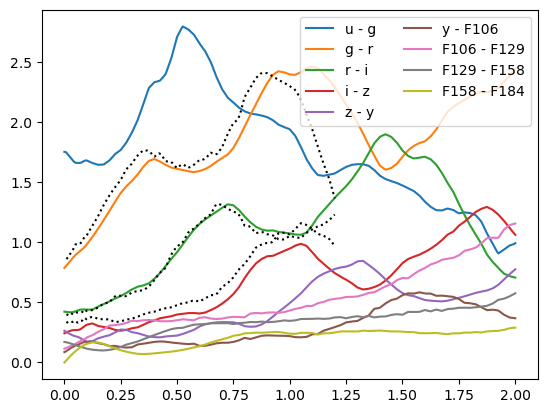

In [31]:
X = fitsio.read(f'{PATH}/initcolors/bc03_colors_{survey}.fit')

n = 0
for i in range(len(bands) - 1):
    plt.plot(X['Z'], X['COLOR'][:, n], label = f'{bands[i].split("_")[1]} - {bands[i + 1].split("_")[1]}')
    n += 1


X = fitsio.read(f'/home/dhayaa/DECADE/redmapper/redmapper/data/initcolors/bc03_colors_sdss.fit')
plt.plot(X['Z'], X['COLOR'], color = 'k', ls = ':')

plt.legend(ncol = 2)